<a href="https://colab.research.google.com/github/karenrosas0410-pixel/Estad-stica-2026B-/blob/main/Copia_de_Problemario_Unidad_5_Parte_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problemario de bloqueo

##Problema 1:
Se hace un estudio sobre la efectividad de tres marcas de atomizador para matar moscas. Para ello, cada producto se aplica a un grupo de 100 moscas, y se cuenta el número de moscas muertas expresado en porcentajes. Se hicieron seis réplicas, pero en días diferentes; por ello, se sospecha que puede haber algún efecto importante debido a esta fuente de variación. Los datos obtenidos se muestran a continuación:

| Marca de atomizador | Réplica 1 | Réplica 2 | Réplica 3 | Réplica 4 | Réplica 5 | Réplica 6 |
|----------------------|-----------|-----------|-----------|-----------|-----------|-----------|
| 1                   | 72        | 65        | 67        | 75        | 62        | 73        |
| 2                   | 55        | 59        | 68        | 70        | 53        | 50        |
| 3                   | 64        | 74        | 61        | 58        | 51        | 69        |

**Preguntas:**<br>
a) Suponiendo un DBCA, formule las hipótesis adecuadas y el modelo estadístico.  
b) ¿Existe diferencia entre la efectividad promedio de los atomizadores?  
c) ¿Hay algún atomizador mejor? Argumente su respuesta.  
d) ¿Hay diferencias significativas en los resultados de diferentes días en que se realizó el experimento? Argumente su respuesta.  
e) Verifique los supuestos de normalidad y de igual varianza entre las marcas.


:Tabla con marca replica y moscas
paso 1 anova  mosca
comprobar supuestos
tukey solo con la v arfiable de interes que es marca



In [ ]:
# Diana Karen Rosas Ortega
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: No hay diferencia
# H1: Al menos una media es diferente

# Datos del problema
data = {
    'marca': [1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3],
    'replica': [1, 2, 3, 4, 5, 6, 1, 2, 3, 4, 5, 6, 1, 2, 3, 4, 5, 6],
    'moscas': [72, 65, 67, 75, 62, 73, 55, 59, 68, 70, 53, 50, 64, 74, 61, 58, 51, 69]
}
df = pd.DataFrame(data)

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols('moscas ~ C(marca) + C(replica)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(marca),296.333333,2.0,2.880752,0.102804
C(replica),281.333333,5.0,1.093973,0.420718
Residual,514.333333,10.0,NaN,NaN


Ho: Todas las marcas son iguales
Hi: Almenos una es diferente         

Ho: Todas las replicas son iguales
Hi: No hay diferencias significativas entre replicas


valor-p (Shapiro) = 0.5541005255267678


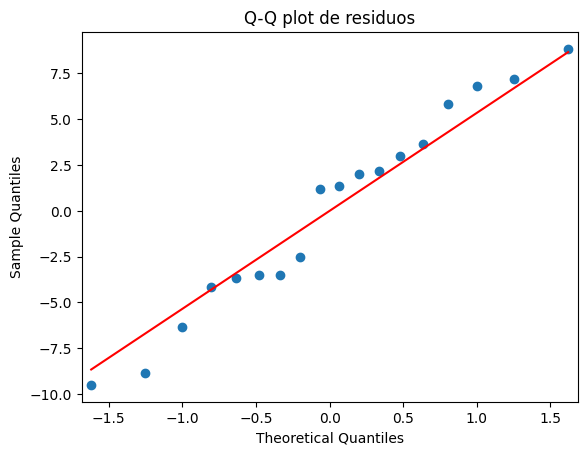

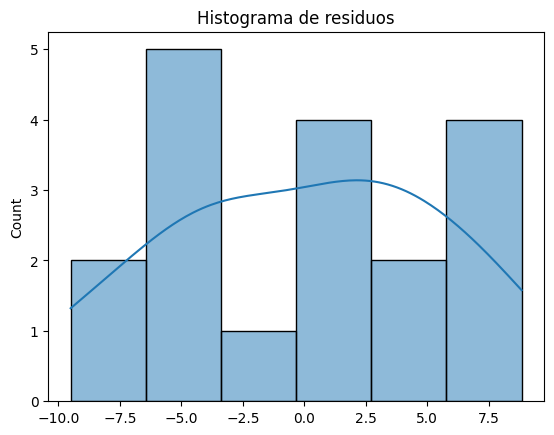

In [ ]:
# Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

Ho: Cumple el supuesto de normalidad

Hi: No cumple el supueto de normalidad

In [ ]:
# Diana Karen Rosas Ortega
from scipy.stats import levene

#H0:Homoscedasticidad
#H1:Heteroscedasticidad
#Nivel de significancia de 0.5

# Extract the 'moscas' data for each 'marca' group using numerical IDs
grupo1 = df[df['marca'] == 1]['moscas']
grupo2 = df[df['marca'] == 2]['moscas']
grupo3 = df[df['marca'] == 3]['moscas']

# Perform Levene's test with the three extracted groups
stat, p = levene(grupo1, grupo2, grupo3)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.5999140287120529


Ho: Cumple el supuesto de homocedasticidad

Hi: No cumple el supuesto de homocedasticidad

##Problema 2:
En una empresa lechera se tienen varios silos para almacenar leche (cisternas de 60 000 L). Un aspecto crítico para que se conserve la leche es la temperatura de almacenamiento. Se sospecha que en algunos silos hay problemas, por ello, durante cinco días se decide registrar la temperatura a cierta hora crítica. Obviamente la temperatura de un día a otro es una fuente de variabilidad que podría impactar la variabilidad total.

| Silo | Lunes | Martes | Miércoles | Jueves | Viernes |
|------|-------|--------|-----------|--------|---------|
| A    | 4.0   | 4.0    | 5.0       | 0.5    | 3.0     |
| B    | 5.0   | 6.0    | 2.0       | 4.0    | 4.0     |
| C    | 4.5   | 4.0    | 3.5       | 2.0    | 3.0     |
| D    | 2.5   | 4.0    | 6.5       | 4.5    | 4.0     |
| E    | 4.0   | 4.0    | 3.5       | 2.0    | 4.0     |

**Preguntas:**<br>
a) En este problema, ¿cuál es el factor de tratamiento y cuál el factor de bloque?  
b) Suponga un DBCA, formule las hipótesis adecuadas y el modelo estadístico.  
c) ¿Hay diferencia entre los silos?  
d) ¿La temperatura de un día a otro es diferente?  
e) Revise residuos, ¿hay algún problema evidente?


a) El factor de tratamiento serian las horas  y el factor bloque los dias

In [ ]:
# Diana Karen Rosas Ortega
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05 # si el valor p es mayor a alfa se acepta ho
# H0: No hay diferencia
# H1: Al menos una media es diferente

# Datos del problema 2 (wide format as given in problem description)
raw_data_problem2 = {
    'Silo': ['A', 'B', 'C', 'D', 'E'],
    'Lunes': [4.0, 5.0, 4.5, 2.5, 4.0],
    'Martes': [4.0, 6.0, 4.0, 4.0, 4.0],
    'Miércoles': [5.0, 2.0, 3.5, 6.5, 3.5],
    'Jueves': [0.5, 4.0, 2.0, 4.5, 2.0],
    'Viernes': [3.0, 4.0, 3.0, 4.0, 4.0]
}
df_wide = pd.DataFrame(raw_data_problem2)

# Convert to long format for ANOVA
df = df_wide.melt(id_vars='Silo', var_name='Dia', value_name='Temperatura')

# Realizar el modelo ANOVA de dos vías para Problema 2
# Factors: Silo and Dia, Response: Temperatura
modelo_lineal = ols('Temperatura ~ C(Silo) + C(Dia)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(Silo),4.46,4.0,0.690402,0.609212
C(Dia),9.76,4.0,1.510836,0.246022
Residual,25.84,16.0,NaN,NaN


Ho: El dia no afecta en la temperatura de los silos

valor-p (Shapiro) = 0.15278501378716636


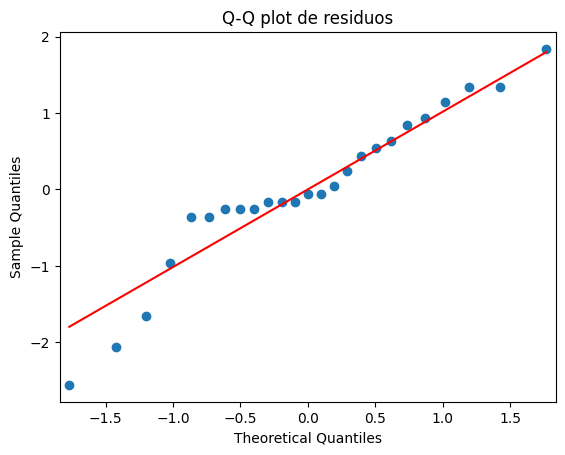

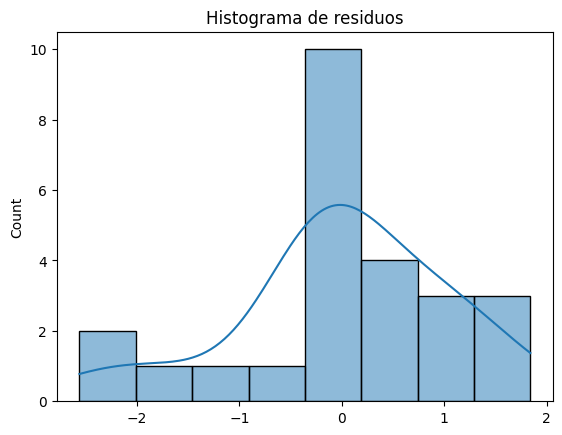

In [ ]:
# Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

Shapiro nos da un valor = a 0.1527 que es mayor al nivel de significancia por lo tanto anova esta bien

In [ ]:
# Diana Karen Rosas Ortega
from scipy.stats import levene

#H0:Homoscedasticidad
#H1:Heteroscedasticidad
#Nivel de significancia de 0.5

# Extract the 'Temperatura' data for each 'Silo' group using string IDs
grupo1 = df[df['Silo'] == 'A']['Temperatura']
grupo2 = df[df['Silo'] == 'B']['Temperatura']
grupo3 = df[df['Silo'] == 'C']['Temperatura']
grupo4 = df[df["Silo"] == 'D']["Temperatura"]
grupo5 = df[df["Silo"] == 'E']["Temperatura"]

# Perform Levene's test with all extracted groups
stat, p = levene(grupo1, grupo2, grupo3, grupo4, grupo5)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.8915311038595306


Valor es meyor al nivel de significancia por lo tanto hay homocedasticidad

## Problema 3
Se diseñó un experimento para estudiar el rendimiento de cuatro detergentes. Las siguientes lecturas de “blancura” se obtuvieron con un equipo especial diseñado para 12 cargas de lavado, distribuidas en tres modelos de lavadoras:

| Detergente | Lavadora 1 | Lavadora 2 | Lavadora 3 |
|------------|------------|------------|------------|
| A          | 45         | 43         | 51         |
| B          | 47         | 44         | 52         |
| C          | 50         | 49         | 57         |
| D          | 42         | 37         | 49         |

**Preguntas:**<br>
a) Señale el nombre del diseño experimental utilizado.  
b) Formule la hipótesis que se quiere probar en este problema.  
c) Realice el análisis estadístico más apropiado para estos datos y obtenga conclusiones.  



a) El diseño experimental utiliozado es DBCA

b) Ho:  Los cuatro detergentes tienen un rendimiento promedio diferente
   
   Hi: Al menos uno de los detergentes tiene un renndimiento promedio diferente  

In [ ]:
# Diana Karen Rosas Ortega
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05 # si el valor p es mayor a alfa se acepta ho
# H0: No hay diferencia
# H1: Al menos una media es diferente

# Datos del problema 3 (wide format as given in problem description)
raw_data_problem3 = {
    'Detergente': ['A', 'B', 'C', 'D'],
    'Lavadora 1': [45,47,50,42],
    'Lavadora 2': [43,44,49,37],
    'Lavadora 3': [51,52,57,49],

}
df_wide = pd.DataFrame(raw_data_problem3)

# Convert to long format for ANOVA
df = df_wide.melt(id_vars='Detergente', var_name='Lavadora', value_name='Blancura')

# Realizar el modelo ANOVA de dos vías para Problema 3
# Factors: Detergente and Lavadora, Response: Blancura
modelo_lineal = ols('Blancura ~ C(Detergente) + C(Lavadora)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(Detergente),133.666667,3.0,34.127660,0.000363
C(Lavadora),170.166667,2.0,65.170213,0.000085
Residual,7.833333,6.0,NaN,NaN


En la anova podemos observar que si existe diferencia significativa tanto en los detergentes como en las lavadoras por lo tanto se rechaza Ho

valor-p (Shapiro) = 0.8945576994890176


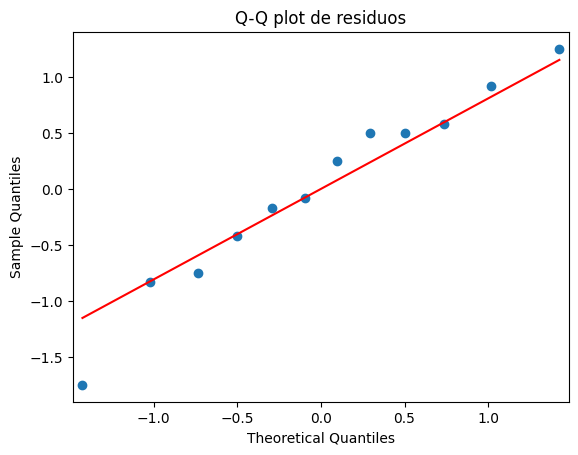

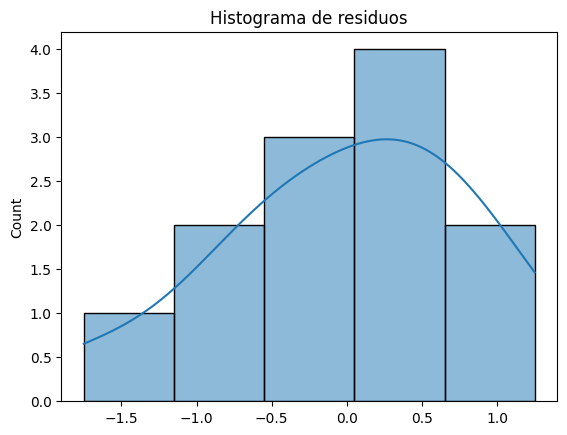

In [ ]:
 #Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

El valor p es de 0.89 lo cual es mayor al nivel de significancia por lo tanto se acepta Ho

In [ ]:
# Diana Karen Rosas Ortega
from scipy.stats import levene

#H0:Homoscedasticidad
#H1:Heteroscedasticidad
#Nivel de significancia de 0.5

# Extract the 'Blancura' data for each 'Detergente' group
grupo_A = df[df['Detergente'] == 'A']['Blancura']
grupo_B = df[df['Detergente'] == 'B']['Blancura']
grupo_C = df[df['Detergente'] == 'C']['Blancura']
grupo_D = df[df['Detergente'] == 'D']['Blancura']

# Perform Levene's test with all extracted groups
stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.9432760038375858


El valor p es mayor al de significancia por lo tanto se acepta Ho pero tenemos que hacer tukey

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B   1.3333 0.9847 -11.0002 13.6669  False
     A      C   5.6667  0.495  -6.6669 18.0002  False
     A      D  -3.6667  0.779 -16.0002  8.6669  False
     B      C   4.3333 0.6855  -8.0002 16.6669  False
     B      D     -5.0 0.5887 -17.3336  7.3336  False
     C      D  -9.3333 0.1495 -21.6669  3.0002  False
-----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

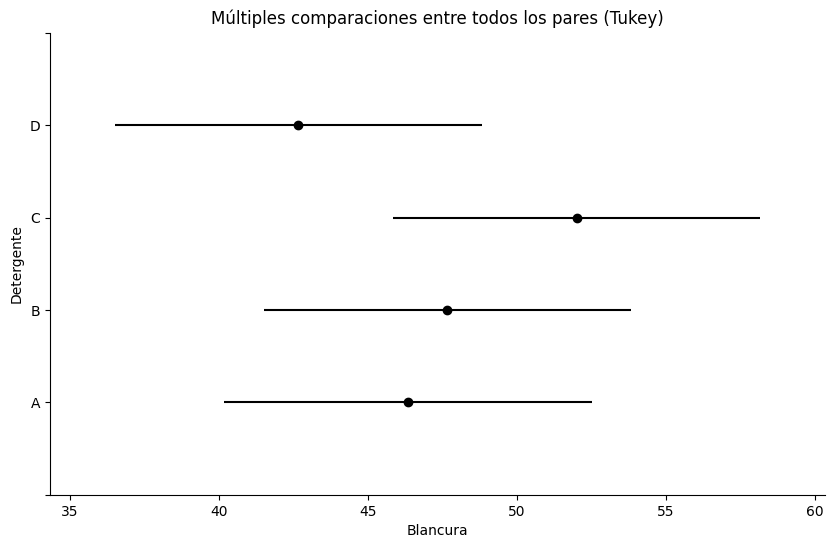

In [ ]:
#Diana Karen Rosas Ortega
#TUKEY
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Blancura'], groups=df['Detergente'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Detergente", xlabel="Blancura")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")


Con respecto a tukey se podria decir que aunque el detergente D presenta un promedio menor no necesariamente existe diferencia significativa con todos lod detergentes

## Problema 4
Con respecto al problema anterior:<br>
a) Conteste los tres incisos del problema anterior sin tomar en cuenta el efecto de las lavadoras y obtenga conclusiones.  
b) ¿Hay diferencias en las conclusiones anteriores y las del problema anterior? Explique su respuesta.  
c) ¿Con cuáles conclusiones se queda? Explique su respuesta.

In [ ]:
import pandas as pd
from io import StringIO

datos = '''
Detergente,Blancura
A,45
A,43
A,51
B,47
B,44
B,52
C,50
C,49
C,57
D,42
D,37
D,49
'''
df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df


,Detergente,Blancura
0,A,45
1,A,43
2,A,51
3,B,47
4,B,44
5,B,52
6,C,50
7,C,49
8,C,57
9,D,42


In [ ]:
#Diana Karen Rosas Ortega
#ANOVA
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05
# H0: Todas las medias son iguales
# H1: Al menos una media es distinta

# Realizar el modelo ANOVA de dos vías
modelo_lineal = ols(f'Blancura ~ Detergente', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
Detergente,133.666667,3.0,2.002497,0.19229
Residual,178.000000,8.0,NaN,NaN


Con respecto a anova se acepta Ho

B) Desde anova si existe una diferencia con respecto a las conclusiones anteriores, ya que el no aplicar las variables de lavadora nos dice que todas las medias son iguales y en el ejercicio 3 dice que una es diferente

valor-p (Shapiro) = 0.14533139517179772


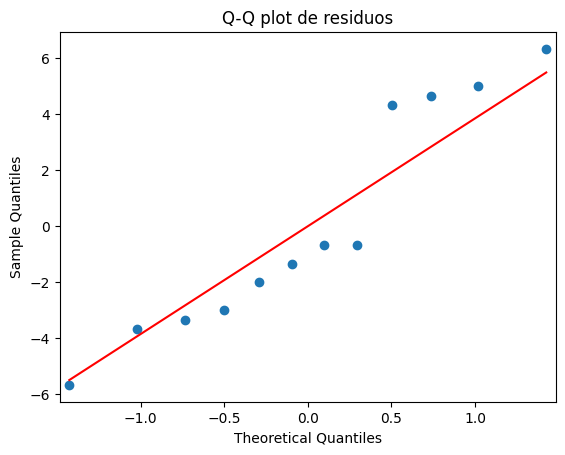

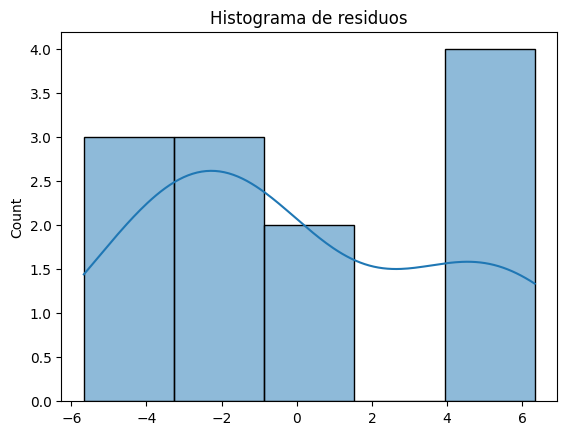

In [ ]:
#Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()


Aqui se pueden observar que hay un cambio en los puntos del grafico, pero aunn asi sigue existiendo normalidad

In [ ]:
# Diana Karen Rosas Ortega
from scipy.stats import levene

#H0:Homoscedasticidad
#H1:Heteroscedasticidad
#Nivel de significancia de 0.5

# Extract the 'Blancura' data for each 'Detergente' group
grupo_A = df[df['Detergente'] == 'A']['Blancura']
grupo_B = df[df['Detergente'] == 'B']['Blancura']
grupo_C = df[df['Detergente'] == 'C']['Blancura']
grupo_D = df[df['Detergente'] == 'D']['Blancura']

# Perform Levene's test with all extracted groups
stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.9432760038375858


C) Me quedo con las segundas conclusiones ya que a lo que pude entender la lavadora no implica de gran significancia que tanta blancura genera un detergente

## Problema 5
Una de las variables críticas en el proceso de ensamble del brazo lector de un disco duro es el ángulo que este forma con el cuerpo principal de la cabeza lectora. Se corre un experimento con el objetivo de comparar dos equipos que miden dicho ángulo en unidades de radianes. Se decide utilizar como factor de bloque a los operadores de los equipos. Los resultados se muestran en la siguiente tabla:

| Operador | Equipo 1                                         | Equipo 2                                         |
|----------|--------------------------------------------------|--------------------------------------------------|
| 1        | 1.328, 0.985, 1.316, 1.553, 1.310               | 1.273, 0.985, 1.134, 1.412, 0.917               |
|          | 1.113, 1.057, 1.144, 1.485, 1.386               | 0.789, 0.671, 0.554, 1.386, 1.289               |
| 2        | 1.269, 1.268, 1.091, 1.195, 1.380               | 1.036, 0.783, 1.108, 1.129, 1.132               |
|          | 1.093, 0.984, 1.087, 1.482, 1.442               | 0.201, 0.900, 0.916, 1.434, 1.223               |
| 3        | 1.440, 1.079, 1.389, 1.611, 1.445               | 1.454, 1.063, 1.219, 1.602, 1.583               |
|          | 1.150, 1.190, 1.247, 1.617, 1.574               | 1.018, 1.050, 0.997, 1.538, 1.478               |

### Preguntas y ejercicios:
a) Plantee el modelo y las hipótesis más adecuadas al problema.  
b) ¿Existen diferencias entre los equipos? Argumente estadísticamente.  
c) ¿Existen diferencias entre los operadores?  
d) Dibuje los diagramas de cajas simultáneos y las gráficas de medias para ambos factores, después interprételas.  
e) Verifique los supuestos de normalidad e igualdad de varianza entre tratamientos, así como la posible presencia de puntos aberrantes.


A) El modelo planteado es DBCA

Ho: No existe diferencia entre los equipos
Hi: Existe diferencia entre los equipos


In [ ]:
import pandas as pd
from io import StringIO

datos = '''
Operador,Equipo,Angulo
1,Equipo 1,1.328
1,Equipo 1,0.985
1,Equipo 1,1.316
1,Equipo 1,1.553
1,Equipo 1,1.310
1,Equipo 1,1.113
1,Equipo 1,1.057
1,Equipo 1,1.144
1,Equipo 1,1.485
1,Equipo 1,1.386
1,Equipo 2,1.273
1,Equipo 2,0.985
1,Equipo 2,1.134
1,Equipo 2,1.412
1,Equipo 2,0.917
1,Equipo 2,0.789
1,Equipo 2,0.671
1,Equipo 2,0.554
1,Equipo 2,1.386
1,Equipo 2,1.289
2,Equipo 1,1.269
2,Equipo 1,1.268
2,Equipo 1,1.091
2,Equipo 1,1.195
2,Equipo 1,1.380
2,Equipo 1,1.093
2,Equipo 1,0.984
2,Equipo 1,1.087
2,Equipo 1,1.482
2,Equipo 1,1.442
2,Equipo 2,1.036
2,Equipo 2,0.783
2,Equipo 2,1.108
2,Equipo 2,1.129
2,Equipo 2,1.132
2,Equipo 2,0.201
2,Equipo 2,0.900
2,Equipo 2,0.916
2,Equipo 2,1.434
2,Equipo 2,1.223
3,Equipo 1,1.440
3,Equipo 1,1.079
3,Equipo 1,1.389
3,Equipo 1,1.611
3,Equipo 1,1.445
3,Equipo 1,1.150
3,Equipo 1,1.190
3,Equipo 1,1.247
3,Equipo 1,1.617
3,Equipo 1,1.574
3,Equipo 2,1.454
3,Equipo 2,1.063
3,Equipo 2,1.219
3,Equipo 2,1.602
3,Equipo 2,1.583
3,Equipo 2,1.018
3,Equipo 2,1.050
3,Equipo 2,0.997
3,Equipo 2,1.538
3,Equipo 2,1.478
'''
df_problema5 = pd.read_csv(StringIO(datos))
df_problema5.reset_index(drop=True, inplace=True)

df_problema5

,Operador,Equipo,Angulo
0,1,Equipo 1,1.328
1,1,Equipo 1,0.985
2,1,Equipo 1,1.316
3,1,Equipo 1,1.553
4,1,Equipo 1,1.310
5,1,Equipo 1,1.113
6,1,Equipo 1,1.057
7,1,Equipo 1,1.144
8,1,Equipo 1,1.485
9,1,Equipo 1,1.386


In [ ]:
# Diana Karen Rosas Ortega
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05 # si el valor p es mayor a alfa se acepta ho
# H0: No hay diferencia
# H1: Al menos una media es diferente

# The raw_data_problem3 was for Problema 3, not Problema 5.
# We need to use the data loaded for Problema 5 or define it correctly.
# Assuming 'df' from cell 6jJO6y6TBfng is the correct DataFrame for Problema 5.

# Realizar el modelo ANOVA de dos vías para Problema 5
# Factors: Operador and Equipo, Response: Angulo
# Use the 'df' DataFrame created in the previous cell (6jJO6y6TBfng)
# which contains 'Operador', 'Equipo', and 'Angulo'.

# Correcting the ols formula to use 'Angulo' as response and 'Operador', 'Equipo' as factors.
modelo_lineal = ols('Angulo ~ C(Operador) + C(Equipo)', data=df_problema5).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(Operador),0.588721,2.0,4.834997,0.011561
C(Equipo),0.492502,1.0,8.089543,0.006205
Residual,3.409351,56.0,NaN,NaN


B) En los resultados de anovacon respecto a los equipos podemos observar que el valor p es menor al nivel de significancia, por lo tanto si existe diferencia estadisticamennte significativa entre los equipos, esto quiere decir que al menos uno de los equipos mide el angulo de diferente manera.

C) Con respectoa anova podemos ver que el valor p es menor que al de significancia por lo tanto rechazamos Ho, esto quiere decir que si existen diferencias significativas entre los operadores, indicando entonces que el operador influye en la medicion del angulo.

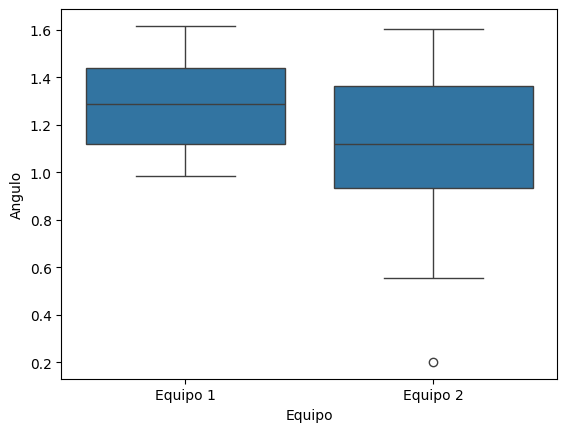

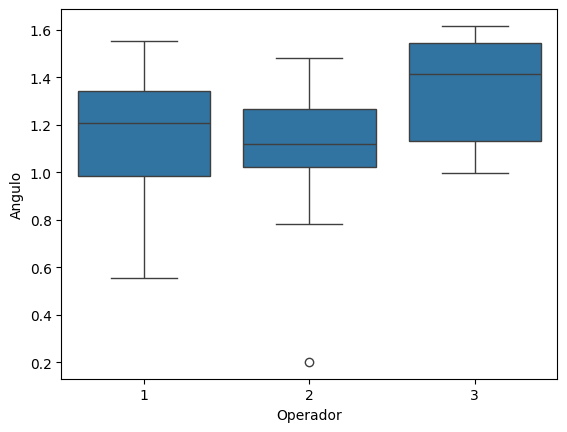

Equipo
Equipo 1    1.290333
Equipo 2    1.109133
Name: Angulo, dtype: float64
Operador
1    1.15435
2    1.10765
3    1.33720
Name: Angulo, dtype: float64


In [ ]:
#Grafica de medias para equipos
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Equipo', y='Angulo', data=df_problema5)
plt.show()

#Grafica de medias operdor
sns.boxplot(x='Operador', y='Angulo', data=df_problema5)
plt.show()

promedio_equipo = df_problema5.groupby('Equipo')['Angulo'].mean()
print(promedio_equipo)

promedio_operador = df_problema5.groupby('Operador')['Angulo'].mean()
print(promedio_operador)


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2  -0.0467 0.8395 -0.2458 0.1524  False
     1      3   0.1829  0.078 -0.0162 0.3819  False
     2      3   0.2296 0.0201  0.0305 0.4286   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

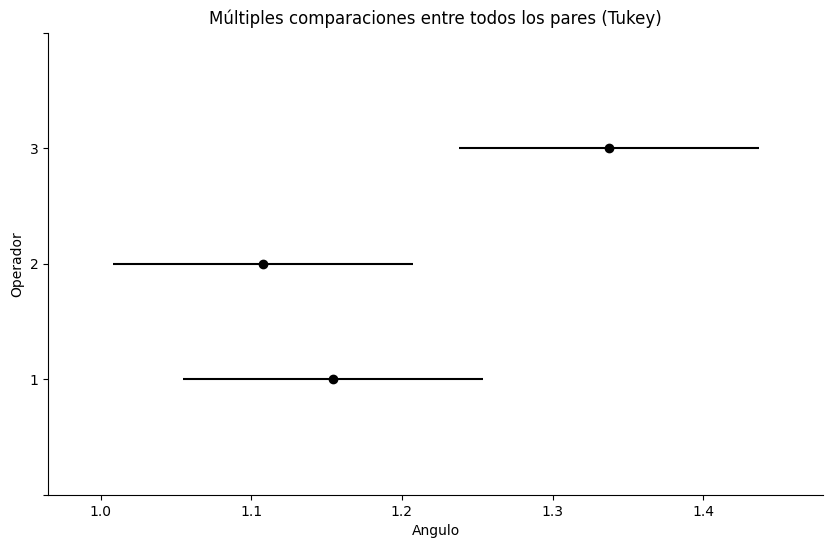

In [ ]:
#Diana Karen Rosas Ortega
#TUKEY
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df_problema5['Angulo'], groups=df_problema5['Operador'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Operador", xlabel="Angulo")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")


C) Se puede observar que entre los operadores 1 y 2 no existe una diferencia asi como tambien en los operadores 1 y 3 ya que se traslapan las lineas, entonces el operador 3 si tiene una diferencia significativa.

valor-p (Shapiro) = 0.05501647805168102


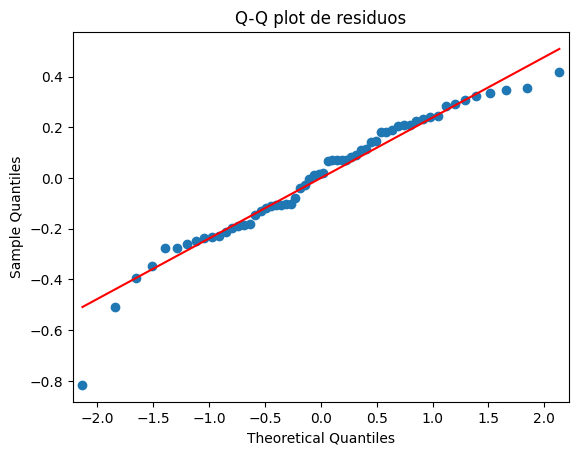

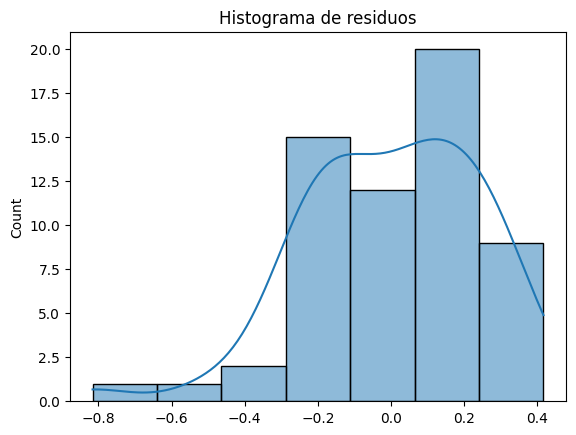

In [ ]:
# Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

Nos da como resultado un valor mayo al de significancia por lo tanto se acepta Ho: si hay normalidad

In [ ]:
# Diana Karen Rosas Ortega
from scipy.stats import levene

#H0:Homoscedasticidad
#H1:Heteroscedasticidad
#Nivel de significancia de 0.5

# Extract the 'Angulo' data for each 'Operador' group (Problema 5)
grupo_1 = df_problema5[df_problema5['Operador'] == 1]['Angulo']
grupo_2 = df_problema5[df_problema5['Operador'] == 2]['Angulo']
grupo_3 = df_problema5[df_problema5['Operador'] == 3]['Angulo']

# Perform Levene's test with all extracted groups
stat, p = levene(grupo_1, grupo_2, grupo_3)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.8316443606977768


Nos dio un valor mayor al de significancia por lo tanto si existe homosedasticidad

## Problema 6
Un aspecto crítico para que se conserve la leche es la temperatura de almacenamiento. De manera tradicional se han usado termómetros de mercurio (Mer) para verificar que la temperatura sea la adecuada, pero ahora se han comprado termómetros electrónicos (Rtd) para facilitar el proceso de medición. Sin embargo, se duda de las mediciones de estos nuevos dispositivos. Para aclarar dudas y diagnosticar la situación, durante cinco días se toman mediciones con ambos tipos de termómetros en varios silos (a la misma hora). Los datos para cinco silos se muestran a continuación:

| Silo | Día 1 (Mer) | Día 1 (Rtd) | Día 2 (Mer) | Día 2 (Rtd) | Día 3 (Mer) | Día 3 (Rtd) | Día 4 (Mer) | Día 4 (Rtd) | Día 5 (Mer) | Día 5 (Rtd) |
|------|-------------|-------------|-------------|-------------|-------------|-------------|-------------|-------------|-------------|--|
| A    | 4.0         | 2.6         | 4.0         | 2.8         | 5.0         | 5.0         | 0.5         | 0.0         | 3.0         | 2.4         |
| B    | 5.0         | 6.4         | 6.0         | 6.4         | 2.0         | 2.3         | 4.0         | 4.2         | 4.0         | 4.0         |
| C    | 4.5         | 3.3         | 4.0         | 1.4         | 3.5         | 1.8         | 2.0         | -1.9        | 3.0         | -7.6        |
| D    | 2.5         | 3.1         | 4.0         | 5.0         | 6.5         | 6.6         | 4.5         | 2.7         | 4.0         | 4.0         |
| E    | 4.0         | 0.0         | 4.0         | 3.5         | 0.6         | 2.0         | -4.0        | -4.0        | -4.0        | -6.3        |

**Preguntas:**<br>
a) Observe los datos y establezca una conjetura acerca de la confiabilidad de las mediciones con Rtd (del termómetro de mercurio no hay duda).  
b) Es claro que el silo se puede ver como tratamiento y día como bloque. Considere sólo los datos de Rtd y establezca el modelo estadístico. También haga el ANOVA correspondiente y obtenga conclusiones.  
c) Repita el inciso anterior pero ahora para las mediciones Mer.  
d) ¿Las conclusiones obtenidas en los incisos anteriores coinciden? Comente su respuesta.  
e) Datos pareados. Para comparar los dos métodos de medición (Mer y Rtd) obtenga como variable de respuesta la diferencia de temperatura que registran los métodos para cada día en cada silo. Considerando esto, establezca el modelo estadístico, haga el ANOVA correspondiente y obtenga conclusiones.


A) Se podria sospechar que las mediciones del termometro electronico podrian presentar menor confiabilidad con respecto al termometro de mercurio, esto puede ser debido a la variedad observada entre ambos metodos de medicion.

In [ ]:
import pandas as pd
from io import StringIO

datos = '''
Silo,Dia,Rtd
A,Dia 1,2.6
A,Dia 2,2.8
A,Dia 3,5.0
A,Dia 4,0.0
A,Dia 5,2.4
B,Dia 1,6.4
B,Dia 2,6.4
B,Dia 3,2.3
B,Dia 4,4.2
B,Dia 5,4.0
C,Dia 1,3.3
C,Dia 2,1.4
C,Dia 3,1.8
C,Dia 4,-1.9
C,Dia 5,-7.6
D,dia 1,3.1
D,Dia 2,5.0
D,Dia 3,6.6
D,Dia 4,2.7
D,Dia 5,4.0
E,Dia 1,4.0
E,Dia 2,3.5
E,Dia 3,2.0
E,Dia 4,-4.0
E,Dia 5,-6.3
'''
df_problema6 = pd.read_csv(StringIO(datos))
df_problema6.reset_index(drop=True, inplace=True)

df_problema6

,Silo,Dia,Rtd
0,A,Dia 1,2.6
1,A,Dia 2,2.8
2,A,Dia 3,5.0
3,A,Dia 4,0.0
4,A,Dia 5,2.4
5,B,Dia 1,6.4
6,B,Dia 2,6.4
7,B,Dia 3,2.3
8,B,Dia 4,4.2
9,B,Dia 5,4.0


In [ ]:
# Diana Karen Rosas Ortega
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05 # si el valor p es mayor a alfa se acepta ho
# H0: No hay diferencia
# H1: Al menos una media es diferente

# The raw_data_problem3 was for Problema 3, not Problema 5.
# We need to use the data loaded for Problema 5 or define it correctly.
# Assuming 'df' from cell 6jJO6y6TBfng is the correct DataFrame for Problema 5.

# Realizar el modelo ANOVA de dos vías para Problema 5
# Factors: Operador and Equipo, Response: Angulo
# Use the 'df' DataFrame created in the previous cell (6jJO6y6TBfng)
# which contains 'Operador', 'Equipo', and 'Angulo'.

# Correcting the ols formula to use 'Angulo' as response and 'Operador', 'Equipo' as factors.
modelo_lineal = ols('Rtd ~ C(Silo) + C(Dia)', data=df_problema6).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(Silo),132.0075,4.0,5.705718,0.005369
C(Dia),111.4440,5.0,3.853527,0.019093
Residual,86.7600,15.0,NaN,NaN


B) Los valores obtenidos son menores al de significancia entonces rechazamos Ho, por lo tanto nos indica que la temperatura promedio no es igual en todos los silos

In [ ]:
import pandas as pd
from io import StringIO

datos = '''
Silo,Dia,Mer
A,Dia 1,4.0
A,Dia 2,4.0
A,Dia 3,5.0
A,Dia 4,0.5
A,Dia 5,3.0
B,Dia 1,5.0
B,Dia 2,6.0
B,Dia 3,2.0
B,Dia 4,4.0
B,Dia 5,4.0
C,Dia 1,4.5
C,Dia 2,4.0
C,Dia 3,3.5
C,Dia 4,2.0
C,Dia 5,3.0
D,dia 1,2.5
D,Dia 2,4.0
D,Dia 3,6.5
D,Dia 4,4.5
D,Dia 5,4.0
E,Dia 1,4.0
E,Dia 2,4.0
E,Dia 3,0.6
E,Dia 4,-4.0
E,Dia 5,-4.0
'''
df_problema6 = pd.read_csv(StringIO(datos))
df_problema6.reset_index(drop=True, inplace=True)

df_problema6

,Silo,Dia,Mer
0,A,Dia 1,4.0
1,A,Dia 2,4.0
2,A,Dia 3,5.0
3,A,Dia 4,0.5
4,A,Dia 5,3.0
5,B,Dia 1,5.0
6,B,Dia 2,6.0
7,B,Dia 3,2.0
8,B,Dia 4,4.0
9,B,Dia 5,4.0


In [ ]:
# Diana Karen Rosas Ortega
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05 # si el valor p es mayor a alfa se acepta ho
# H0: No hay diferencia
# H1: Al menos una media es diferente

# The raw_data_problem3 was for Problema 3, not Problema 5.
# We need to use the data loaded for Problema 5 or define it correctly.
# Assuming 'df' from cell 6jJO6y6TBfng is the correct DataFrame for Problema 5.

# Realizar el modelo ANOVA de dos vías para Problema 5
# Factors: Operador and Equipo, Response: Angulo
# Use the 'df' DataFrame created in the previous cell (6jJO6y6TBfng)
# which contains 'Operador', 'Equipo', and 'Angulo'.

# Correcting the ols formula to use 'Angulo' as response and 'Operador', 'Equipo' as factors.
modelo_lineal = ols('Mer ~ C(Silo) + C(Dia)', data=df_problema6).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(Silo),67.1535,4.0,4.904866,0.009908
C(Dia),45.5460,5.0,2.661330,0.064799
Residual,51.3420,15.0,NaN,NaN


D) LOs valores obtenidos fueron menores al nivel de significancia entonces se rechaza la Ho para silo,
como el valor del dia es mayor al de significancia se acepta Ho  esto quiere decir que no existe diferencia significativa entre los dias.

Las conclsuiones obtenidas en ambos ANOVA no coinciden en ambos metodos de medicion


In [ ]:
#Diana Karen Rosas Ortega
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

silos = ['A','B','C','D','E']
dias = [1,2,3,4,5]

mer = [
[4.0,4.0,5.0,0.5,3.0],
[5.0,6.0,2.0,4.0,4.0],
[4.5,4.0,3.5,2.0,3.0],
[2.5,4.0,6.5,4.5,4.0],
[4.0,4.0,0.6,4.0,4.0]
]

rtd = [
[2.6,2.8,5.0,0.0,2.4],
[6.4,6.4,2.3,4.2,4.0],
[3.3,1.4,1.8,1.9,7.6],
[3.1,5.0,6.6,2.7,4.0],
[0.0,3.5,2.0,4.0,6.3]
]

datos = []

for i, silo in enumerate(silos):
    for j, dia in enumerate(dias):
        diferencia = mer[i][j] - rtd[i][j]
        datos.append([silo, dia, diferencia])

df = pd.DataFrame(datos,
                  columns=['Silo','Dia','Diferencia'])

modelo = ols('Diferencia ~ C(Silo)+C(Dia)',
             data=df).fit()

anova = sm.stats.anova_lm(modelo, typ=2)
print(anova)

           sum_sq    df         F    PR(>F)
C(Silo)    3.6904   4.0  0.306782  0.869195
C(Dia)    14.3864   4.0  1.195937  0.350504
Residual  48.1176  16.0       NaN       NaN


In [ ]:
# Diana Karen Rosas Ortega
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05 # si el valor p es mayor a alfa se acepta ho
# H0: No hay diferencia
# H1: Al menos una media es diferente

# The raw_data_problem3 was for Problema 3, not Problema 5.
# We need to use the data loaded for Problema 5 or define it correctly.
# Assuming 'df' from cell 6jJO6y6TBfng is the correct DataFrame for Problema 5.

# Realizar el modelo ANOVA de dos vías para Problema 5
# Factors: Operador and Equipo, Response: Angulo
# Use the 'df' DataFrame created in the previous cell (6jJO6y6TBfng)
# which contains 'Operador', 'Equipo', and 'Angulo'.

# Correcting the ols formula to use 'Angulo' as response and 'Operador', 'Equipo' as factors.
# For Problem 6 part e), the response variable is 'Diferencia' and factors are 'Silo' and 'Dia' from 'df' DataFrame.
modelo_lineal = ols('Diferencia ~ C(Silo) + C(Dia)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(Silo),3.6904,4.0,0.306782,0.869195
C(Dia),14.3864,4.0,1.195937,0.350504
Residual,48.1176,16.0,NaN,NaN


E) Al obtener los resultados de ambos termometros podemos observar que los valores ya cambiaron, ahora son mayor que al nivel de significancia, por lo tanto se hacepta Ho , esto quiere decir que no existe diefrencia entre los silos y que tampoco no existe dieferncia entre los dias.


## Problema 7
Se quiere estudiar el efecto de cinco diferentes catalizadores (**A, B, C, D y E**) sobre el **tiempo de reacción** de un proceso químico. Cada lote de material sólo permite cinco corridas y cada corrida requiere aproximadamente 1.5 horas, por lo que sólo se pueden realizar cinco corridas diarias. El experimentador decide correr los experimentos con un diseño en cuadro latino para controlar activamente a los **lotes y días**. Los datos obtenidos son:

| Lote | Día 1 | Día 2 | Día 3 | Día 4 | Día 5 |
|------|-------|-------|-------|-------|-------|
| 1    | A = 8 | B = 7 | D = 1 | C = 7 | E = 3 |
| 2    | C = 11| E = 2 | A = 7 | D = 3 | B = 8 |
| 3    | B = 4 | A = 9 | C = 10| E = 1 | D = 5 |
| 4    | D = 6 | C = 8 | E = 6 | B = 6 | A = 10|
| 5    | E = 4 | D = 2 | B = 3 | A = 8 | C = 8 |


**Preguntas:**<br>
a) ¿Cómo se aleatorizó el experimento?  
b) Anote la ecuación del modelo y las hipótesis estadísticas correspondientes.  
c) ¿Existen diferencias entre los tratamientos? ¿Cuáles tratamientos son diferentes entre sí?  
d) ¿Los factores de ruido, lote y día afectan el tiempo de reacción del proceso?  
e) Dibuje los gráficos de medias para los tratamientos, los lotes y los días. ¿Cuál tratamiento es mejor?  
f) Verifique los supuestos del modelo, considerando que los datos se obtuvieron columna por columna, día a día.


A) El experimento se realizo mediante un diseño en cuadro latino, en donde los tratamientos son los catalizadores osea ( A,B,C,D,E) los lotes son las filas y los dias columnas.

La aletarizacion consistio en asignar los 5 catalizadores de manera que  cada catalizador apareciera una sola vez por lote y una sola vez por dia.


B) HO: El tiempo de reaccion es igual para todos los catalizadores

Hi: Existe diferencia en el tiempo de reaccion entre al menos dos catalizadores

In [5]:
import pandas as pd
from io import StringIO

datos = '''
catalizadores,tiempo,dia,lote
A,8,Dia 1,1
C,11,Dia 1,2
B,4,Dia 1,3
D,6,Dia 1,4
E,4,Dia 1,5
B,7,Dia 2,1
E,2,Dia 2,2
A,9,Dia 2,3
C,8,Dia 2,4
D,2,Dia 2,5
D,1,Dia 3,1
A,7,Dia 3,2
C,10,Dia 3,3
E,6,Dia 3,4
B,3,Dia 3,5
C,7,Dia 4,1
D,3,Dia 4,2
E,1,Dia 4,3
B,6,Dia 4,4
A,8,Dia 4,5
E,3,Dia 5,1
B,8,Dia 5,2
D,5,Dia 5,3
A,10,Dia 5,4
C,8,Dia 5,5
'''
df_problema6 = pd.read_csv(StringIO(datos))
df_problema6.reset_index(drop=True, inplace=True)

df_problema6

,catalizadores,tiempo,dia,lote
0,A,8,Dia 1,1
1,C,11,Dia 1,2
2,B,4,Dia 1,3
3,D,6,Dia 1,4
4,E,4,Dia 1,5
5,B,7,Dia 2,1
6,E,2,Dia 2,2
7,A,9,Dia 2,3
8,C,8,Dia 2,4
9,D,2,Dia 2,5


In [7]:
# Diana Karen Rosas Ortega
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05 # si el valor p es mayor a alfa se acepta ho
# H0: No hay diferencia
# H1: Al menos una media es diferente

# Correcting the ols formula to use 'Angulo' as response and 'Operador', 'Equipo' as factors.
modelo_lineal = ols('tiempo ~ C(catalizadores) + C(lote) + C(dia)', data=df_problema6).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(catalizadores),141.44,4.0,11.309168,0.000488
C(lote),15.44,4.0,1.234542,0.347618
C(dia),12.24,4.0,0.978678,0.455014
Residual,37.52,12.0,NaN,NaN


C) Con anova podemos observar que el valor p es menor al de significancia por lo tanto si existe diferencia significativa entre los tratamientos con respecto al tiempo de reaccion

D) El valor p de lote es mayor al nivel de significancia por lo tanto los lotes no afectan al tiempo de reacccion.

Para dia el valor de significancia es mayor a p por lo tanto el dia no afecta al tiempo de reaccion

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B     -2.8 0.1423 -6.2171  0.6171  False
     A      C      0.4 0.9965 -3.0171  3.8171  False
     A      D     -5.0 0.0024 -8.4171 -1.5829   True
     A      E     -5.2 0.0016 -8.6171 -1.7829   True
     B      C      3.2 0.0733 -0.2171  6.6171  False
     B      D     -2.2 0.3361 -5.6171  1.2171  False
     B      E     -2.4 0.2578 -5.8171  1.0171  False
     C      D     -5.4 0.0011 -8.8171 -1.9829   True
     C      E     -5.6 0.0007 -9.0171 -2.1829   True
     D      E     -0.2 0.9998 -3.6171  3.2171  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

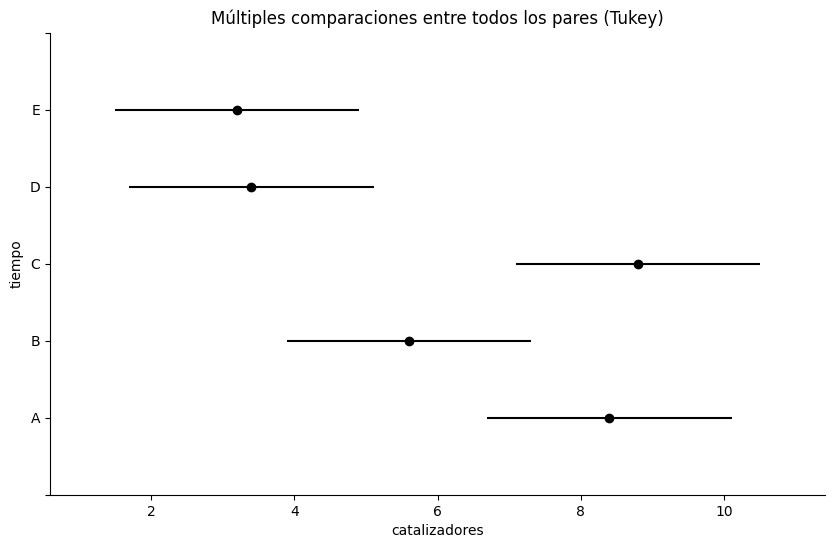

In [10]:
#Diana Karen Rosas Ortega
#TUKEY
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df_problema6['tiempo'], groups=df_problema6['catalizadores'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="tiempo", xlabel="catalizadores")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

El tratamiento E y D tienen ños menores tiempos de reaccion, por lo cual son los mas recomendados

valor-p (Shapiro) = 0.5476371878728195


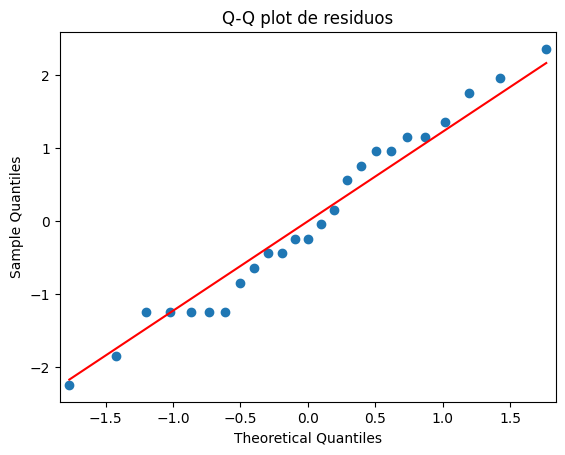

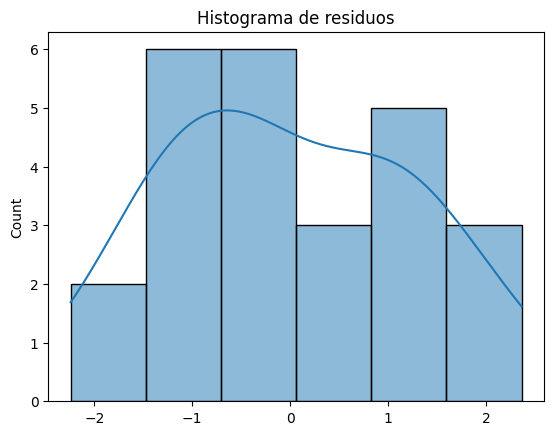

In [11]:
# Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

Se cumple el supuesto de nnormalidad

In [7]:
import pandas as pd
from io import StringIO
from scipy.stats import levene

# Redefining df_problema6 to ensure it's available in this cell's scope
datos = '''
catalizadores,tiempo,dia,lote
A,8,Dia 1,1
C,11,Dia 1,2
B,4,Dia 1,3
D,6,Dia 1,4
E,4,Dia 1,5
B,7,Dia 2,1
E,2,Dia 2,2
A,9,Dia 2,3
C,8,Dia 2,4
D,2,Dia 2,5
D,1,Dia 3,1
A,7,Dia 3,2
C,10,Dia 3,3
E,6,Dia 3,4
B,3,Dia 3,5
C,7,Dia 4,1
D,3,Dia 4,2
E,1,Dia 4,3
B,6,Dia 4,4
A,8,Dia 4,5
E,3,Dia 5,1
B,8,Dia 5,2
D,5,Dia 5,3
A,10,Dia 5,4
C,8,Dia 5,5
'''
import pandas as pd
from io import StringIO
from scipy.stats import levene

# Redefining df_problema6 to ensure it's available in this cell's scope
datos = '''
catalizadores,tiempo,dia,lote
A,8,Dia 1,1
C,11,Dia 1,2
B,4,Dia 1,3
D,6,Dia 1,4
E,4,Dia 1,5
B,7,Dia 2,1
E,2,Dia 2,2
A,9,Dia 2,3
C,8,Dia 2,4
D,2,Dia 2,5
D,1,Dia 3,1
A,7,Dia 3,2
C,10,Dia 3,3
E,6,Dia 3,4
B,3,Dia 3,5
C,7,Dia 4,1
D,3,Dia 4,2
E,1,Dia 4,3
B,6,Dia 4,4
A,8,Dia 4,5
E,3,Dia 5,1
B,8,Dia 5,2
D,5,Dia 5,3
A,10,Dia 5,4
C,8,Dia 5,5
'''
#H0:Homoscedasticidad
#H1:Heteroscedasticidad
#Nivel de significancia de 0.5

# Extract the 'tiempo' data for each 'catalizadores' group
grupo_A = df_problema6[df_problema6['catalizadores'] == 'A']['tiempo']
grupo_B = df_problema6[df_problema6['catalizadores'] == 'B']['tiempo']
grupo_C = df_problema6[df_problema6['catalizadores'] == 'C']['tiempo']
grupo_D = df_problema6[df_problema6['catalizadores'] == 'D']['tiempo']
grupo_E = df_problema6[df_problema6['catalizadores'] == 'E']['tiempo']

# Perform Levene's test with all extracted groups
stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D, grupo_E)
print(f"p-valor de Levene: {p}")

p-valor de Levene: 0.7751009409046274


Se cumple el supuesto de hommosedasticidad

## Problema 8
En el problema anterior elimine el factor de bloque días, y conteste:

a) ¿Se justifica la eliminación?  
b) Sin tomar en cuenta el día, señale el nombre del diseño, el modelo y las hipótesis más adecuadas al problema.  
c) Pruebe las hipótesis y obtenga conclusiones.  
d) Compare el cuadro medio del error, en este caso con el del problema anterior. ¿Qué observa? ¿Cómo lo explica?  
e) ¿Por qué se obtienen las mismas conclusiones en los tratamientos de este problema y del anterior?


A) Si ayq que en el promea 7 el dia tiene un valor mayor al de significancia, por lo tanto el factor dia no afecta el tiempo de reaccion

B) DBCA

 Ho: No existen diferencias significativas entre los tratamientos

 Hi:Existe diferencia significativa en almenos dos tratamientos



In [8]:
import pandas as pd
from io import StringIO
from scipy.stats import levene

# Redefining df_problema6 to ensure it's available in this cell's scope
datos = '''
catalizadores,tiempo,,lote
A,8,1
C,11,2
B,4,3
D,6,4
E,4,,5
B,7,1
E,2,2
A,9,3
C,8,4
D,2,5
D,1,1
A,7,2
C,10,3
E,6,4
B,3,5
C,7,1
D,3,2
E,1,3
B,6,4
A,8,5
E,3,1
B,8,2
D,5,3
A,10,4
C,8,5
'''

df_problema6 = pd.read_csv(StringIO(datos))
df_problema6.reset_index(drop=True, inplace=True)

df_problema6

,catalizadores,tiempo,Unnamed: 2,lote
0,A,8,1.0,NaN
1,C,11,2.0,NaN
2,B,4,3.0,NaN
3,D,6,4.0,NaN
4,E,4,NaN,5.0
5,B,7,1.0,NaN
6,E,2,2.0,NaN
7,A,9,3.0,NaN
8,C,8,4.0,NaN
9,D,2,5.0,NaN


In [10]:
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm
from io import StringIO

# Nivel de significancia = 0.05 # si el valor p es mayor a alfa se acepta ho
# H0: No hay diferencia
# H1: Al menos una media es diferente

# Redefining df_problema6 to ensure it's correctly structured for this analysis.
# This data corresponds to the Latin Square design of Problema 7, which Problem 8 modifies.
datos = '''
catalizadores,tiempo,dia,lote
A,8,Dia 1,1
C,11,Dia 1,2
B,4,Dia 1,3
D,6,Dia 1,4
E,4,Dia 1,5
B,7,Dia 2,1
E,2,Dia 2,2
A,9,Dia 2,3
C,8,Dia 2,4
D,2,Dia 2,5
D,1,Dia 3,1
A,7,Dia 3,2
C,10,Dia 3,3
E,6,Dia 3,4
B,3,Dia 3,5
C,7,Dia 4,1
D,3,Dia 4,2
E,1,Dia 4,3
B,6,Dia 4,4
A,8,Dia 4,5
E,3,Dia 5,1
B,8,Dia 5,2
D,5,Dia 5,3
A,10,Dia 5,4
C,8,Dia 5,5
'''
df_problema6 = pd.read_csv(StringIO(datos))
df_problema6.reset_index(drop=True, inplace=True)

# For Problem 8, we eliminate the 'dia' factor.
# The error with typ=2 is addressed by changing to typ=1 for robust calculation.
modelo_lineal = ols('tiempo ~ C(catalizadores) + C(lote)', data=df_problema6).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=1)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
C(catalizadores),4.0,141.44,35.36,11.369775,0.000146
C(lote),4.0,15.44,3.86,1.241158,0.333144
Residual,16.0,49.76,3.11,NaN,NaN


C) En el valor de catalizador el valor p es menor al de significancia, por lo tanto existen diferencias entre los catalizadores con respecto al tiempp

por otro lado los lotes no afectan al tiempo de reaccion

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B     -2.8 0.1423 -6.2171  0.6171  False
     A      C      0.4 0.9965 -3.0171  3.8171  False
     A      D     -5.0 0.0024 -8.4171 -1.5829   True
     A      E     -5.2 0.0016 -8.6171 -1.7829   True
     B      C      3.2 0.0733 -0.2171  6.6171  False
     B      D     -2.2 0.3361 -5.6171  1.2171  False
     B      E     -2.4 0.2578 -5.8171  1.0171  False
     C      D     -5.4 0.0011 -8.8171 -1.9829   True
     C      E     -5.6 0.0007 -9.0171 -2.1829   True
     D      E     -0.2 0.9998 -3.6171  3.2171  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

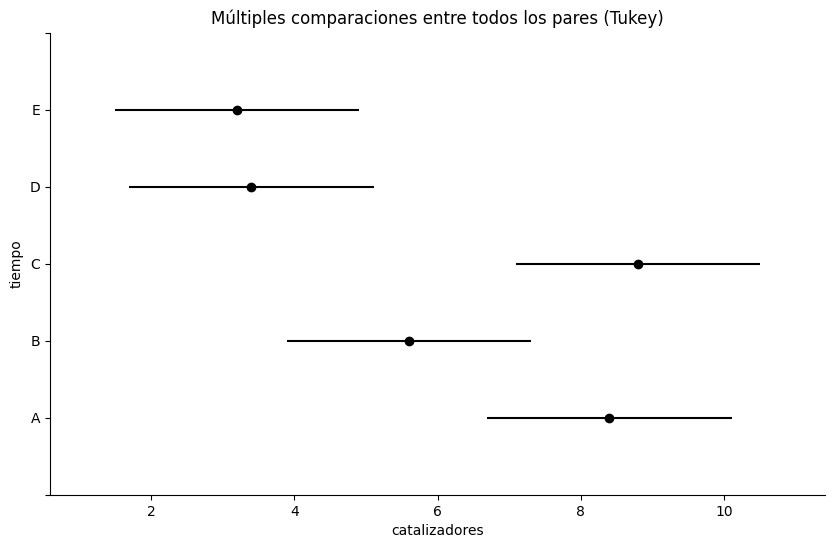

In [11]:
#Diana Karen Rosas Ortega
#TUKEY
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df_problema6['tiempo'], groups=df_problema6['catalizadores'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="tiempo", xlabel="catalizadores")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

Se observa que los resultados de significancia son muy similares, esto ocurre porque el factor dia no era significativo

valor-p (Shapiro) = 0.04246184389935066


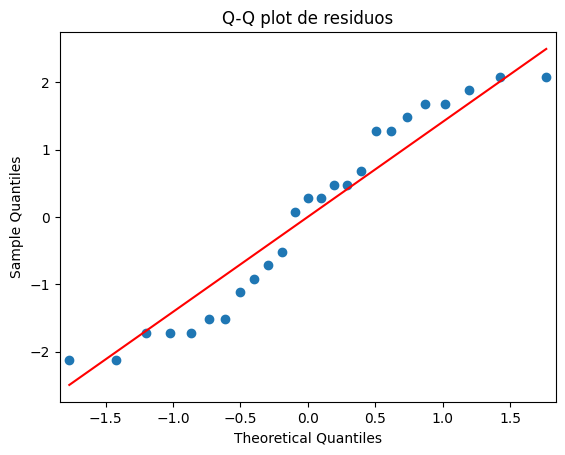

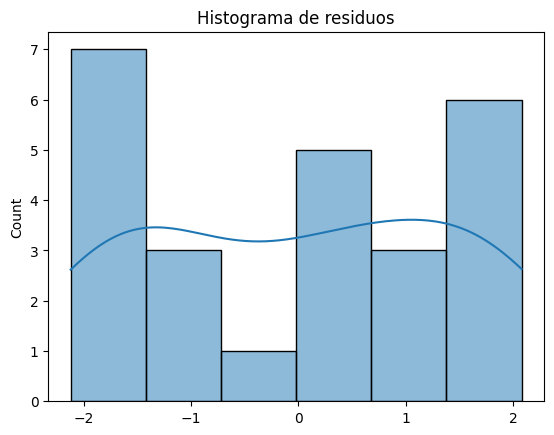

In [12]:
# Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [15]:
#Diana Karen Rosas Ortega
from scipy.stats import levene

# Separar tiempos por catalizador
A = df_problema6[df_problema6['catalizadores']=='A']['tiempo']
B = df_problema6[df_problema6['catalizadores']=='B']['tiempo']
C = df_problema6[df_problema6['catalizadores']=='C']['tiempo']
D = df_problema6[df_problema6['catalizadores']=='D']['tiempo']
E = df_problema6[df_problema6['catalizadores']=='E']['tiempo']

# Prueba de Levene
levene_test = levene(A, B, C, D, E)

print("Estadístico:", levene_test.statistic)
print("Valor p:", levene_test.pvalue)

Estadístico: 0.4444444444444445
Valor p: 0.7751009409046274


Se cumple el supuesto


E) Se obtienen los mimso resultados ya que el factor dia no influye en mucha informacion

## Problema 9
Con respecto a los problemas 7 y 8, además de eliminar el factor día ahora elimine el factor lote, y conteste lo siguiente:

a) ¿Se justifica esta segunda eliminación en ambos problemas?  
b) Después de la doble eliminación, señale el nombre del diseño, el modelo y la(s) hipótesis más adecuada(s) al problema.  
c) Pruebe las hipótesis y obtenga conclusiones.  
d) Compare el cuadro medio del error obtenido con los de los problemas 16 y 17. ¿Qué observa? ¿Cómo lo explica?  
e) ¿Por qué se obtienen las mismas conclusiones en los tratamientos de este problema y de los dos anteriores?  
f) ¿Cree que esta eliminación hubiese afectado si los factores de bloque hubieran sido significativos?  


A ) Si se justifica eliminar lote ya que en los problemas anteriores no presento un valor significativo

b) DCA

Ho: los catalizadores no afectan el tiempo de reaccion

Hi: Al menos un catalizador afecta el tiempo de reaccion


In [16]:
import pandas as pd
from io import StringIO

datos = '''
catalizadores,tiempo
A,8
C,11
B,4
D,6
E,4
B,7
E,2
A,9
C,8
D,2
D,1
A,7
C,10
E,6
B,3
C,7
D,3
E,1
B,6
A,8
E,3
B,8
D,5
A,10
C,8
'''
df_problema6 = pd.read_csv(StringIO(datos))
df_problema6.reset_index(drop=True, inplace=True)

df_problema6

,catalizadores,tiempo
0,A,8
1,C,11
2,B,4
3,D,6
4,E,4
5,B,7
6,E,2
7,A,9
8,C,8
9,D,2


In [19]:
 #Diana Karen Rosas Ortega
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05 # si el valor p es mayor a alfa se acepta ho
# H0: No hay diferencia
# H1: Al menos una media es diferente

# Delete conflicting Series variables (A, B, C, D, E) from global scope
# These were defined in a previous cell for Levene's test and are causing a name collision with patsy's C()
for var_name in ['A', 'B', 'C', 'D', 'E']:
    if var_name in globals():
        del globals()[var_name]

# Correcting the ols formula to use 'Angulo' as response and 'Operador', 'Equipo' as factors.
modelo_lineal = ols('tiempo ~ C(catalizadores)', data=df_problema6).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(catalizadores),141.44,4.0,10.846626,0.000077
Residual,65.20,20.0,NaN,NaN


C) El anova nos mostro un valor p menor al de significancia por lo cual existen diferencias significativas entre los catalizadores


Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B     -2.8 0.1423 -6.2171  0.6171  False
     A      C      0.4 0.9965 -3.0171  3.8171  False
     A      D     -5.0 0.0024 -8.4171 -1.5829   True
     A      E     -5.2 0.0016 -8.6171 -1.7829   True
     B      C      3.2 0.0733 -0.2171  6.6171  False
     B      D     -2.2 0.3361 -5.6171  1.2171  False
     B      E     -2.4 0.2578 -5.8171  1.0171  False
     C      D     -5.4 0.0011 -8.8171 -1.9829   True
     C      E     -5.6 0.0007 -9.0171 -2.1829   True
     D      E     -0.2 0.9998 -3.6171  3.2171  False
----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

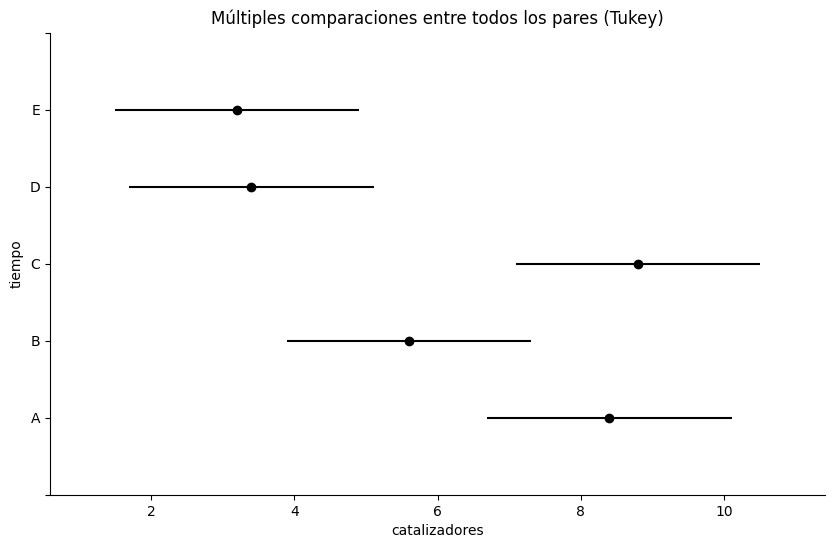

In [20]:
#Diana Karen Rosas Ortega
#TUKEY
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df_problema6['tiempo'], groups=df_problema6['catalizadores'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="tiempo", xlabel="catalizadores")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

valor-p (Shapiro) = 0.29334160847597135


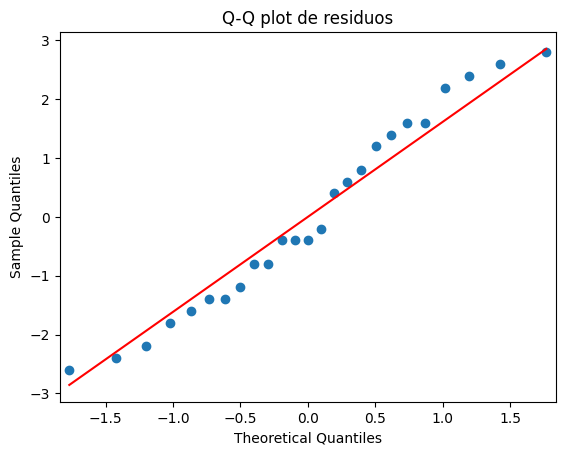

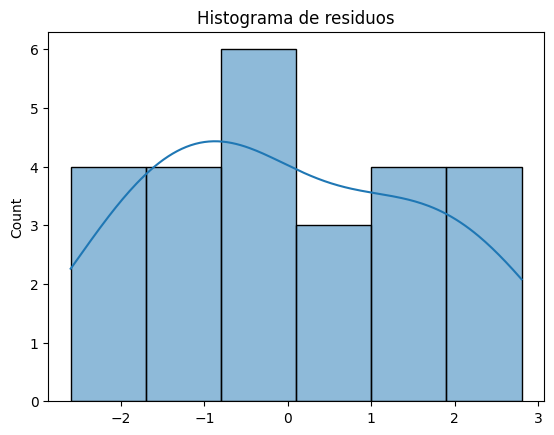

In [21]:
 #Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [22]:
#Diana Karen Rosas Ortega
from scipy.stats import levene

# Separar tiempos por catalizador
A = df_problema6[df_problema6['catalizadores']=='A']['tiempo']
B = df_problema6[df_problema6['catalizadores']=='B']['tiempo']
C = df_problema6[df_problema6['catalizadores']=='C']['tiempo']
D = df_problema6[df_problema6['catalizadores']=='D']['tiempo']
E = df_problema6[df_problema6['catalizadores']=='E']['tiempo']

# Prueba de Levene
levene_test = levene(A, B, C, D, E)

print("Estadístico:", levene_test.statistic)
print("Valor p:", levene_test.pvalue)

Estadístico: 0.4444444444444445
Valor p: 0.7751009409046274


D) El modelo del rpoblema 7 era el mas preciso, despues el del 8 y el 9 tiene menor capacidada de analizar los datos

E) SE obtienen las mismas conclusiones porque igual manera el factor lote no fue significativo en el analisis

f) si los resultados hubieran sido significativos si hubiera influido

## Problema 11
Cuando se comparan varios fertilizantes o diferentes variedades de cierto cultivo, es típico que se deba considerar el gradiente de fertilidad del suelo (factor columna) o los efectos residuales de cultivos previos (factor renglón). Considerando estos factores de bloque, Gomez y Gomez (1984) plantean un experimento en cuadro latino para comparar, en cuanto a rendimiento en toneladas por hectárea, tres variedades de maíz híbrido (**A, B, C**) y una variedad control (**D**). Para ello, se utiliza un campo agrícola cuadrado de 16 hectáreas, dividido en parcelas de una hectárea. Los datos de rendimiento obtenidos en cada parcela se muestran a continuación:

| Ren\Col | 1       | 2       | 3       | 4       |
|---------|---------|---------|---------|---------|
| 1       | 1.640(B)| 1.210(D)| 1.425(C)| 1.345(A)|
| 2       | 1.475(C)| 1.185(A)| 1.400(D)| 1.290(B)|
| 3       | 1.670(A)| 0.710(C)| 1.665(B)| 1.180(D)|
| 4       | 1.565(D)| 1.290(B)| 1.655(A)| 0.660(C)|

**Preguntas y ejercicios:**<br>
a) ¿Existen diferencias en los rendimientos de las diferentes variedades de maíz?  
b) ¿Cuál de los factores de bloque tuvo efectos?  
c) ¿Se habrían detectado las mismas diferencias en los tratamientos con un diseño completamente al azar?  
d) ¿Y con un diseño en bloques completos al azar?  


In [6]:
import pandas as pd
from io import StringIO

datos = '''
fila,columna,tratamiento,Rendimiento
1,1,B,1.640
1,2,D,1.210
1,3,C,1.425
1,4,A,1.345
2,1,C,1.475
2,2,A,1.185
2,3,D,1.400
2,4,B,1.290
3,1,A,1.670
3,2,C,0.710
3,3,B,1.665
3,4,D,1.180
4,1,D,1.565
4,2,B,1.290
4,3,A,1.655
4,4,C,0.660
'''
df_problema6 = pd.read_csv(StringIO(datos))
df_problema6.reset_index(drop=True, inplace=True)

df_problema6

,fila,columna,tratamiento,Rendimiento
0,1,1,B,1.640
1,1,2,D,1.210
2,1,3,C,1.425
3,1,4,A,1.345
4,2,1,C,1.475
5,2,2,A,1.185
6,2,3,D,1.400
7,2,4,B,1.290
8,3,1,A,1.670
9,3,2,C,0.710


In [8]:
#Diana Karen Rosas Ortega
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05 # si el valor p es mayor a alfa se acepta ho
# H0: No hay diferencia
# H1: Al menos una media es diferente

# Delete conflicting Series variables (A, B, C, D, E) from global scope
# These were defined in a previous cell for Levene's test and are causing a name collision with patsy's C()
for var_name in ['A', 'B', 'C', 'D', 'E']:
    if var_name in globals():
        del globals()[var_name]

# Correcting the ols formula to use 'Angulo' as response and 'Operador', 'Equipo' as factors.
modelo_lineal = ols('Rendimiento ~ C(fila) + C(columna) + C(tratamiento)', data=df_problema6).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(fila),0.030155,3.0,0.465406,0.716972
C(columna),0.827342,3.0,12.769166,0.005148
C(tratamiento),0.426842,3.0,6.587865,0.025092
Residual,0.129584,6.0,NaN,NaN


A ) Ho: Las medias de rendimiento de las variedades son iguales

Hi: Al menos una variedad presenta un rendimiento diferente

Con respecto a los resultados, si esxiste diferencia entre los rendimientos de las variedades del maiz

B) el factor correspondiente a las columnas tuvo efecto significativo sobre el rendimiento.

C) Un diseño al azar seria menos eficiente para detectar las diferencias observadas

D) El diseño de bloques completos al azar seria mejor que un diseño completamente al azar.


valor-p (Shapiro) = 0.20260853040992488


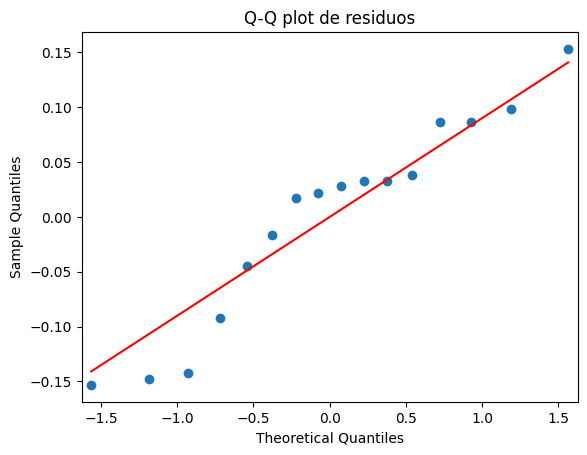

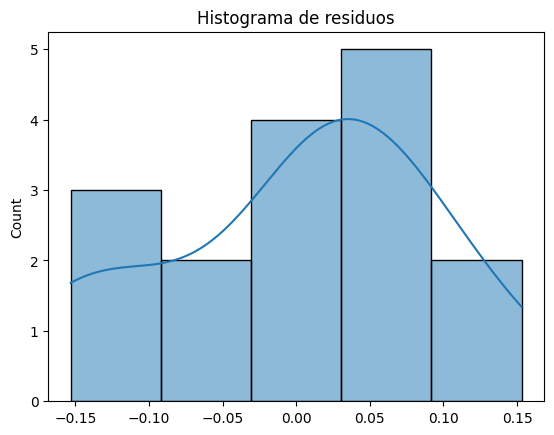

In [9]:
#Diana Karen Rosas Ortega
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#H0:Si hay normalidad
#H1:No hay normalidad
#Nivel de significancia de 0.5

residuos = modelo_lineal.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [20]:
#Diana Karen Rosas Ortega
from scipy.stats import levene
import pandas as pd
from io import StringIO

# Reloading df_problema6 with data for Problem 11, as it was overwritten.
datos = '''
fila,columna,tratamiento,Rendimiento
1,1,B,1.640
1,2,D,1.210
1,3,C,1.425
1,4,A,1.345
2,1,C,1.475
2,2,A,1.185
2,3,D,1.400
2,4,B,1.290
3,1,A,1.670
3,2,C,0.710
3,3,B,1.665
3,4,D,1.180
4,1,D,1.565
4,2,B,1.290
4,3,A,1.655
4,4,C,0.660
'''
df_problema6 = pd.read_csv(StringIO(datos))
df_problema6.reset_index(drop=True, inplace=True)

# Separar tiempos por catalizador
A = df_problema6[df_problema6['tratamiento']=='A']['Rendimiento']
B = df_problema6[df_problema6['tratamiento']=='B']['Rendimiento']
C = df_problema6[df_problema6['tratamiento']=='C']['Rendimiento']
D = df_problema6[df_problema6['tratamiento']=='D']['Rendimiento']

# Prueba de Levene
levene_test = levene(A, B, C, D)

print("Estadístico:", levene_test.statistic)
print("Valor p:", levene_test.pvalue)

Estadístico: 13.683854739820791
Valor p: 0.00035260549065253474


## Problema 12
Se quieren comparar tres dietas (**A, B, C**) a base de proteínas de origen vegetal utilizando 18 ratas de laboratorio de una misma camada. Primero se observa por un tiempo el apetito para formar tres grupos de seis ratas, según su voracidad; y cada uno de estos grupos se clasifica a su vez en tres grupos de dos ratas, de acuerdo a su peso inicial. Se plantea un experimento donde la variable de respuesta es el peso en gramos ganado por las ratas después de cierto periodo, con los siguientes resultados:

| Apetito/peso inicial | A1        | A2        | A3        |
|-----------------------|-----------|-----------|-----------|
| P1                   | 67 (C)    | 105 (A)   | 95 (B)    |
|                       | 72        | 112       | 86        |
| P2                   | 85 (A)    | 75 (B)    | 88 (C)    |
|                       | 98        | 67        | 110       |
| P3                   | 66 (B)    | 68 (C)    | 108 (A)   |
|                       | 47        | 91        | 120       |

### Preguntas:
a) Analice los datos. ¿Cuáles de los factores influyen en el peso ganado por las ratas?  
b) ¿Cuál dieta es mejor?  
c) ¿Alguno de los factores de bloque puede ser ignorado? Argumente su respuesta.  
d) Si ese fuera el caso, analice de nuevo el experimento y saque conclusiones.  
e) Verifique los supuestos del modelo.  


In [18]:
#Diana Karen Rosas Ortega
import pandas as pd
from io import StringIO

datos = '''
Apetito,Peso inicial,Ganancia,Dieta
P1,A1,67,C
P1,A1,72,C
P1,A2,105,A
P1,A2,112,A
P1,A3,95,B
P1,A3,86,B
P2,A1,85,A
P2,A1,98,A
P2,A2,75,B
P2,A2,67,B
P2,A3,88,C
P2,A3,110,C
P3,A1,47,B
P3,A2,68,C
P3,A2,91,C
P3,A3,108,A
P3,A3,120,A

'''
df_problema6 = pd.read_csv(StringIO(datos))
df_problema6.rename(columns={'Peso inicial': 'Peso_inicial'}, inplace=True)
df_problema6.reset_index(drop=True, inplace=True)

df_problema6

,Apetito,Peso_inicial,Ganancia,Dieta
0,P1,A1,67,C
1,P1,A1,72,C
2,P1,A2,105,A
3,P1,A2,112,A
4,P1,A3,95,B
5,P1,A3,86,B
6,P2,A1,85,A
7,P2,A1,98,A
8,P2,A2,75,B
9,P2,A2,67,B


In [19]:
#Diana Karen Rosas Ortega
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Nivel de significancia = 0.05 # si el valor p es mayor a alfa se acepta ho
# H0: No hay diferencia
# H1: Al menos una media es diferente

# Delete conflicting Series variables (A, B, C, D, E) from global scope
# These were defined in a previous cell for Levene's test and are causing a name collision with patsy's C()
for var_name in ['A', 'B', 'C', 'D', 'E']:
    if var_name in globals():
        del globals()[var_name]

# Correcting the ols formula to use 'Ganancia' as response and 'Apetito', 'Peso_inicial', 'Dieta' as factors.
# 'Peso inicial' was renamed to 'Peso_inicial' in the DataFrame.
modelo_lineal = ols('Ganancia ~ C(Apetito) + C(Peso_inicial) + C(Dieta)', data=df_problema6).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal, typ=2)
tabla_anova

,sum_sq,df,F,PR(>F)
C(Apetito),230.494172,2.0,1.452778,0.279329
C(Peso_inicial),2642.994172,2.0,16.658481,0.000656
C(Dieta),3394.160839,2.0,21.392996,0.000244
Residual,793.287879,10.0,NaN,NaN


A) el apetito influye de manera significativa


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B -30.6667 0.0167 -55.7777 -5.5557   True
     A      C    -22.0 0.0737 -45.9424  1.9424  False
     B      C   8.6667 0.6471 -16.4443 33.7777  False
-----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

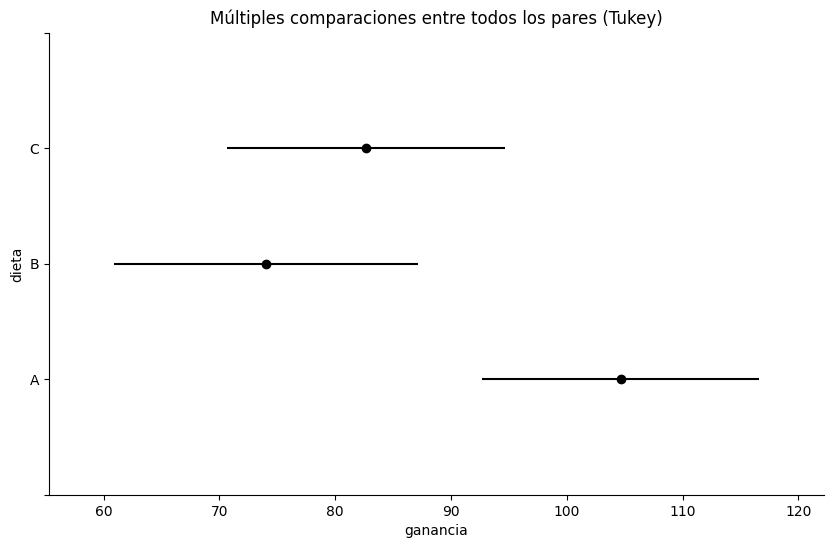

In [23]:
#Diana Karen Rosas Ortega
#TUKEY
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO

nivel_de_significancia = 0.05

# Reloading df_problema6 with data for Problem 12, as it was overwritten.
datos = '''
Apetito,Peso inicial,Ganancia,Dieta
P1,A1,67,C
P1,A1,72,C
P1,A2,105,A
P1,A2,112,A
P1,A3,95,B
P1,A3,86,B
P2,A1,85,A
P2,A1,98,A
P2,A2,75,B
P2,A2,67,B
P2,A3,88,C
P2,A3,110,C
P3,A1,47,B
P3,A2,68,C
P3,A2,91,C
P3,A3,108,A
P3,A3,120,A

'''
df_problema6 = pd.read_csv(StringIO(datos))
df_problema6.rename(columns={'Peso inicial': 'Peso_inicial'}, inplace=True)
df_problema6.reset_index(drop=True, inplace=True)

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df_problema6['Ganancia'], groups=df_problema6['Dieta'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="dieta", xlabel="ganancia")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

B) La dieta a presento la mayor ganancia promedio, seguida por la c y la b

C) si ya que son valores menores al valor de significancia

## Problema 13
Una compañía distribuidora ubicada en los suburbios está interesada en estudiar la diferencia en costos (tiempo y gasolina) entre las cuatro rutas (**A, B, C, D**) que llevan a la zona comercial, más importante para ellos, en el otro extremo de la ciudad. Deciden correr un experimento en cuadro grecolatino controlando los factores de bloque **chofer**, marca de vehículo (**α, β, χ, δ**) y día de la semana. El experimento se repite en dos semanas diferentes, en las cuales no hay días festivos ni quincenas. Los costos observados en pesos se muestran en la siguiente tabla:

| Chofer/día | Lunes       | Martes      | Miércoles   | Jueves      |
|------------|-------------|-------------|-------------|-------------|
| Carlos     | 825(D, α)   | 585(C, χ)   | 550(B, β)   | 580(A, δ)   |
|            | 750         | 610         | 580         | 650         |
| Enrique    | 650(A, χ)   | 540(B, α)   | 580(C, χ)   | 850(D, β)   |
|            | 725         | 560         | 635         | 770         |
| Genaro     | 700(C, β)   | 650(D, δ)   | 635(A, α)   | 450(B, χ)   |
|            | 675         | 740         | 540         | 550         |
| Luis       | 475(B, δ)   | 560(A, β)   | 650(D, α)   | 670(C, α)   |
|            | 480         | 615         | 725         | 730         |

### Preguntas:
a) Haga el análisis de varianza de este experimento.  
b) Realice las pruebas de comparaciones múltiples para los factores significativos.  
c) Represente los tratamientos y factores de bloque usando gráficas de medias y diagramas de dispersión.  
d) ¿Cuál es la mejor ruta? ¿Cuál es la peor?  
e) ¿Hay diferencias significativas entre los choferes? ¿Y entre el tipo o marca de unidad?  
f) ¿Cuáles factores de bloque valió la pena tomar en cuenta en el experimento?  
g) ¿Por qué se evitaron días festivos y quincenas en el experimento? ¿Cuáles otros aspectos se tenían que tomar en cuenta?  
h) Verifique los supuestos del modelo.  


## Problema 14
23. Un investigador está interesado en el efecto del porcentaje de lisina y del porcentaje de proteína en la producción de vacas lecheras. Se consideran siete niveles en cada factor:

- **% de lisina**: 0.0 (**A**), 0.1 (**B**), 0.2 (**C**), 0.3 (**D**), 0.4 (**E**), 0.5 (**F**), 0.6 (**G**).  
- **% de proteína**: 2 (**α**), 4 (**β**), 6 (**χ**), 8 (**δ**), 10 (**ε**), 12 (**φ**), 14 (**γ**).  

Para el estudio, se seleccionaron siete vacas al azar, a las cuales se les da un seguimiento de siete periodos de tres meses. Los datos en galones de leche fueron los siguientes:

| Vaca/periodo | 1       | 2       | 3       | 4       | 5       | 6       | 7       |
|--------------|---------|---------|---------|---------|---------|---------|---------|
| 1            | 304 (Aα)| 436 (Bε)| 350 (Cβ)| 504 (Dφ)| 417 (Eχ)| 519 (Fγ)| 432 (Gδ)|
| 2            | 381 (Bβ)| 505 (Cφ)| 425 (Dχ)| 564 (Eγ)| 487 (Fα)| 536 (Gε)| 483 (Aχ)|
| 3            | 432 (Cχ)| 566 (Dγ)| 479 (Eε)| 357 (Fα)| 466 (Gβ)| 465 (Aφ)| 507 (Bγ)|
| 4            | 442 (Dδ)| 372 (Eχ)| 536 (Fε)| 366 (Gβ)| 495 (Aχ)| 425 (Bφ)| 507 (Cγ)|
| 5            | 496 (Eε)| 449 (Fβ)| 493 (Gφ)| 345 (Aχ)| 509 (Bγ)| 481 (Cδ)| 380 (Dα)|
| 6            | 534 (Fφ)| 421 (Gχ)| 352 (Aγ)| 427 (Bδ)| 346 (Cχ)| 478 (Dε)| 397 (Eβ)|
| 7            | 543 (Gγ)| 386 (Aδ)| 435 (Bα)| 485 (Cε)| 406 (Dφ)| 554 (Eφ)| 410 (Fχ)|

### Preguntas y ejercicios:
a) Analice este experimento. ¿Qué factores tienen efecto en la producción de leche?  
b) Interprete los resultados usando gráficos de medias.  
c) ¿Cómo puede explicar la falta de efectos en vacas y periodo?  
d) ¿Qué porcentajes de lisina y proteína dan los mejores resultados?  
e) Verifique los supuestos del modelo.  
